In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

DATA_PATH = "clean_data_basic.csv"

df_clean = pd.read_csv(DATA_PATH, low_memory=False)
# Some exports use "see the paper" as the first header instead of "paper"
_first = df_clean.columns[0]
if _first != "paper":
    df_clean = df_clean.rename(columns={_first: "paper"})

if "subj_excl" in df_clean.columns and "trial_excl" in df_clean.columns:
    df_clean = df_clean[(~df_clean["subj_excl"]) & (~df_clean["trial_excl"])].copy()

# Match old pipeline: numeric incentive code
if "incentivization_code" not in df_clean.columns:
    inc = df_clean["incentivization"].astype("string")
    df_clean["incentivization_code"] = pd.factorize(inc.fillna("__na__"))[0]

if "reward_ratio" not in df_clean.columns:
    df_clean["reward_ratio"] = df_clean["ll_value"] / df_clean["ss_value"].replace(0, np.nan)
if "delay_diff" not in df_clean.columns:
    df_clean["delay_diff"] = df_clean["ll_time"] - df_clean["ss_time"]
if "rt_log" not in df_clean.columns:
    df_clean["rt_log"] = np.log(df_clean["rt"].where(df_clean["rt"] > 0))

D = df_clean["delay_diff"]
ratio = df_clean["reward_ratio"]
k_thr = (ratio - 1) / D.where(D > 0)
if "log_discount_k" not in df_clean.columns:
    df_clean["log_discount_k"] = np.log(k_thr.where(k_thr > 0))
df_clean["log_discount_k"] = -df_clean["log_discount_k"]

df_clean["patience_rate"] = df_clean.groupby("subj_ident")["choice"].transform("mean")

FEATURE_COLS = [
    "ss_value", "ss_time", "ll_value", "ll_time",
    "rt", "trial_idx", "reward_ratio", "delay_diff",
    "rt_log", "log_discount_k", "patience_rate",
    "time_pressure", "online_study", "incentivization_code",
]

subjects = df_clean["subj_ident"].unique()
train_subj, test_subj = train_test_split(subjects, test_size=0.2, random_state=42)

train = df_clean[df_clean["subj_ident"].isin(train_subj)]
test = df_clean[df_clean["subj_ident"].isin(test_subj)]

sub = FEATURE_COLS + ["choice"]
before = len(train) + len(test)
train = train.dropna(subset=sub)
test = test.dropna(subset=sub)
print(
    f"{DATA_PATH}: {df_clean.shape} | after dropna on features: "
    f"train {train.shape[0]}, test {test.shape[0]} "
    f"(dropped {before - train.shape[0] - test.shape[0]} rows)"
)

clean_data_basic.csv: (1026276, 28) | after dropna on features: train 735701, test 188671 (dropped 101904 rows)


/Users/julie/Desktop/Code-project/hackathon/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


── LOGISTIC REGRESSION ──
Accuracy: 0.7859
ROC-AUC:  0.8658
              precision    recall  f1-score   support

           0       0.77      0.74      0.75     83484
           1       0.80      0.82      0.81    105187

    accuracy                           0.79    188671
   macro avg       0.78      0.78      0.78    188671
weighted avg       0.79      0.79      0.79    188671


── RANDOM FOREST ──
Accuracy: 0.8223
ROC-AUC:  0.9082
              precision    recall  f1-score   support

           0       0.78      0.83      0.80     83484
           1       0.86      0.82      0.84    105187

    accuracy                           0.82    188671
   macro avg       0.82      0.82      0.82    188671
weighted avg       0.82      0.82      0.82    188671



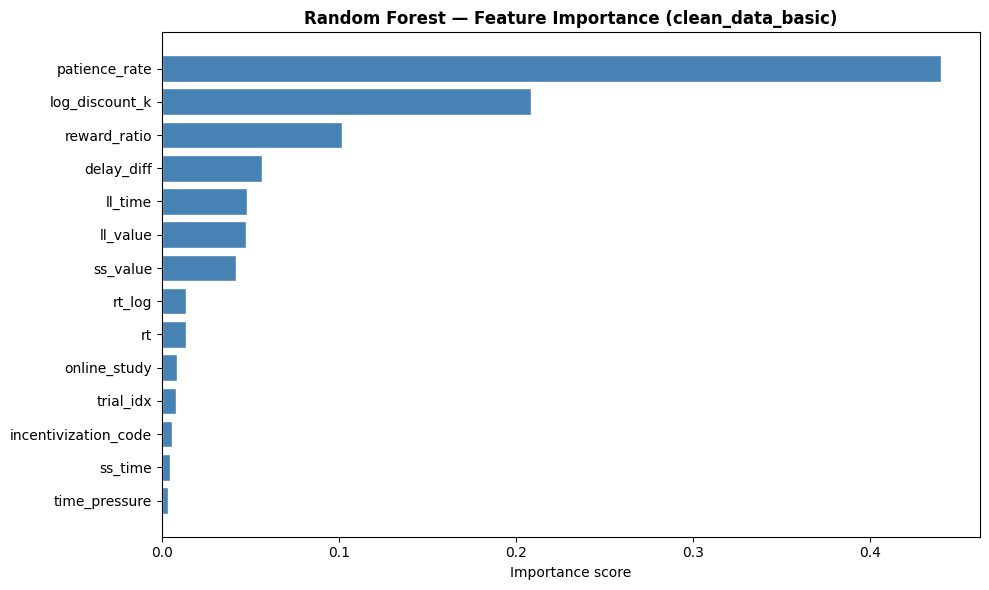

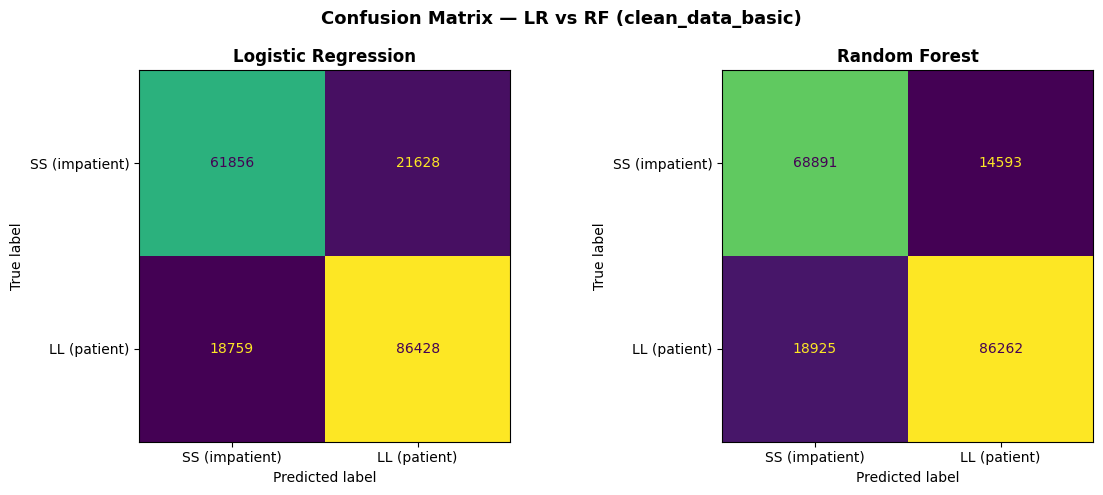

SHAP debug:
  <class 'numpy.ndarray'> (2000, 14, 2)
  X_sample: (2000, 14) | shap_ll (plot): (2000, 14)


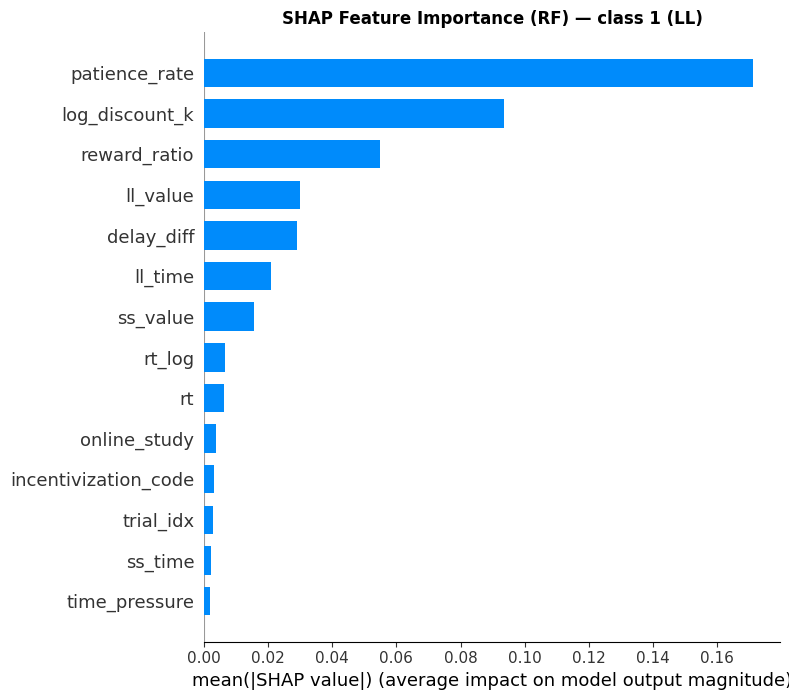


══ MODEL COMPARISON (clean_data_basic) ══
Model                       Accuracy    ROC-AUC
---------------------------------------------
Logistic Regression           0.7859     0.8658
Random Forest                 0.8223     0.9082


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import shap

FEATURE_COLS = [
    "ss_value", "ss_time", "ll_value", "ll_time",
    "rt", "trial_idx", "reward_ratio", "delay_diff",
    "rt_log", "log_discount_k", "patience_rate",
    "time_pressure", "online_study", "incentivization_code",
]

X_train = train[FEATURE_COLS]
y_train = train["choice"]
X_test = test[FEATURE_COLS]
y_test = test["choice"]

# ── 1. LOGISTIC REGRESSION (baseline) ────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("── LOGISTIC REGRESSION ──")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, lr_proba):.4f}")
print(classification_report(y_test, lr_preds))

# ── 2. RANDOM FOREST ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\n── RANDOM FOREST ──")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, rf_proba):.4f}")
print(classification_report(y_test, rf_preds))

# ── 3. FEATURE IMPORTANCE (RF) ────────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"],
         color="steelblue", edgecolor="white")
plt.xlabel("Importance score")
plt.title("Random Forest — Feature Importance (clean_data_basic)", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_rf_importance_basic.png", bbox_inches="tight")
plt.show()

# ── 4. CONFUSION MATRIX ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=axes[0],
    display_labels=["SS (impatient)", "LL (patient)"],
    colorbar=False)
axes[0].set_title("Logistic Regression", fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=axes[1],
    display_labels=["SS (impatient)", "LL (patient)"],
    colorbar=False)
axes[1].set_title("Random Forest", fontweight="bold")

plt.suptitle("Confusion Matrix — LR vs RF (clean_data_basic)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_confusion_matrix_basic.png", bbox_inches="tight")
plt.show()

# ── 5. SHAP VALUES (interpretability) ────────────────────────────────────────
X_sample = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

sv = np.asarray(shap_values)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_ll = np.asarray(shap_values[1])
elif sv.ndim == 3 and sv.shape[-1] == 2:
    shap_ll = sv[..., 1]
elif sv.ndim == 2:
    shap_ll = sv
else:
    shap_ll = sv[..., -1]

print("SHAP debug:")
print(" ", type(shap_values), getattr(shap_values, "shape", None))
if isinstance(shap_values, list):
    print(" ", "len", len(shap_values), "| [0]", np.asarray(shap_values[0]).shape,
          "| [1]", np.asarray(shap_values[1]).shape)
print(" ", "X_sample:", X_sample.shape, "| shap_ll (plot):", np.asarray(shap_ll).shape)

shap.summary_plot(
    shap_ll,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (RF) — class 1 (LL)", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_shap_basic.png", bbox_inches="tight")
plt.show()

# ── 6. MODEL COMPARISON SUMMARY ───────────────────────────────────────────────
print("\n══ MODEL COMPARISON (clean_data_basic) ══")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test, lr_preds):>10.4f} {roc_auc_score(y_test, lr_proba):>10.4f}")
print(f"{'Random Forest':<25} {accuracy_score(y_test, rf_preds):>10.4f} {roc_auc_score(y_test, rf_proba):>10.4f}")